# Statistical analysis using MathArena 
In this notebook we will perform some of the statistical analysis uing the MathAreana datasets. 

## Load all the problem dataset

In [1]:
from datasets import load_dataset
import pandas as pd
# All datasets names
from math_arena_datasets import problem_datasets_2025


In [2]:
from typing import Any
data_dict: dict[str, Any] = {}

for dataset_name in problem_datasets_2025:
  
  data_dict[dataset_name] = load_dataset(f"{dataset_name}")

# It's usually in a 'train' split



## Checking the problem type attribrute
The first step is to go through all the columns of all the datasets, to see if they have different names for the problem type column. If not, we will have have to rename name

In [3]:
# print features for all datasets
all_column_names = set()
for name, dataset in data_dict.items():
  cols = dataset["train"].column_names
  all_column_names = all_column_names.union(cols )
  
all_column_names


# df = pd.DataFrame(ds["train"])
# print(df.columns.tolist())

# # Peek at the first few rows
# print(df.head(3)[["problem_idx","model_name","answer","parsed_answer","correct"]])


{'__index_level_0__',
 'answer',
 'competition',
 'grading_scheme',
 'image',
 'points',
 'problem',
 'problem_idx',
 'problem_type',
 'sample_grading',
 'sample_solution',
 'source'}

### Conclusion
Here we conclude that only "problem type" column in all the datasets is called problem type. So no furhter processing on that

## Find the have problem type cols / have not problem type col ratio
This to determine whether we can actually use this col 

In [4]:
PROBLEM_TYPE_COL = "problem_type"
n_of_has_problem_type_col = 0
n_of_has_not_problem_type_col = 0
datastes_which_has_problem_type = []

for name, dataset in data_dict.items():
  rows = len(dataset["train"])
  if PROBLEM_TYPE_COL in dataset["train"].column_names:
    n_of_has_problem_type_col += rows
    datastes_which_has_problem_type.append(name)
  else:
    n_of_has_not_problem_type_col+=rows

print(f"{n_of_has_problem_type_col=}, {n_of_has_not_problem_type_col=}")
    


n_of_has_problem_type_col=130, n_of_has_not_problem_type_col=397


In [5]:
ratio = n_of_has_problem_type_col/(n_of_has_problem_type_col +n_of_has_not_problem_type_col )
print(f"{ratio*100}%")

24.667931688804554%


### Conclusion
Since 25 % of the dataset contains catagory, we need to fill this catagory of the rest of the dataset. 
The dataset is too small for finetuning with things Like LORA. But, we can try in-context learning. Before this however, we need to fetch all the categories

In [6]:
pruned_dataset_dict = {
  name: dataset for (name, dataset) in data_dict.items() 
  if name in datastes_which_has_problem_type
}

print(f"Remaining {len(pruned_dataset_dict)} out of {len(data_dict)}")
labelled_data = [name for (name, _) in pruned_dataset_dict.items()]
labelled_data

Remaining 4 out of 17


['MathArena/aime_2025',
 'MathArena/hmmt_feb_2025',
 'MathArena/cmimc_2025',
 'MathArena/brumo_2025']

Here we see that actually only 4 remains,


## Column name alignment
Next step is to check that the names of the problem type columns align on the those datasets

In [7]:
from itertools import chain
def flattern(li: list[list]) -> list:
  return [x for sublist in li for x in sublist]  

all_labels = set()
for name, dataset in pruned_dataset_dict.items():
  col = dataset["train"][PROBLEM_TYPE_COL]
  col = set(flattern(col))
  all_labels = all_labels.union(col)

print(all_labels)

{'Geometry', 'Number Theory', 'Algebra', 'Combinatorics'}


So we have 4 catagories, each of which can be present at the same time. 

## Generating labels using in context learning
We investigate wheter we can use a model to generate the labels. 
To do this, we split the data in train, test (no need for validation here)
Though no actual training. 
Then we select a few examples from the train set, evaluate it on the test set

### Train-test spit
We do a 50/50 split. This is only done for a demo. For the final version, we will do a proper test-val-train split by 
- pulling examples from train
- Checking performance on val
- When done, checking on test

In [8]:
from datasets import Dataset, DatasetDict
import pandas as pd
import itertools
# Create a dataframe of all of the data
frames = []
for k, dataset in pruned_dataset_dict.items():
  dfs = {split: dataset.to_pandas() for split, dataset in dataset.items()}
  dfs = dfs["train"]
  dfs = dfs[["problem", "problem_type"]]
  frames.append(dfs)
full_data_pd = pd.concat(frames).reset_index()
assert len(full_data_pd)==130


In [9]:
# Now split the data
train_df = full_data_pd.sample(frac=0.5, random_state=42)
test_df = full_data_pd.drop(train_df.index)
print(len(full_data_pd))
print(f"{len(train_df)=}, {len(test_df)=}")

130
len(train_df)=65, len(test_df)=65


In [10]:
# save the data
train_path = "data/problem_type_data.train.csv"
test_path = "data/problem_type_data.test.csv"
train_df.to_csv(train_path)
test_df.to_csv(test_path)

In [11]:
from datasets import load_dataset
data = load_dataset("csv", 
                    data_files={"train": train_path, "test":test_path})

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

## Setting up the training
1) We pick a text generator model or a classifier model
2) Then, we create problem description. For instance: 
"You are given the task of labelling a set of problems in the categories 
{'Algebra', 'Number Theory', 'Combinatorics', 'Geometry'}. Note that some
problems can have multiple catories. You should output the answer as Categeory: []
Where inside the [] ise the list of categories. For exame Category: [Algebra, Number thoery]"
3) Evaluate this on the test set. 
4) Give the model the same prompt, however, this time add one example from the train set. Evaluate on the test set
5) Continue with more examples one example at a time 
6) Plot the performace and pick the best examples / number example

In [12]:
# # Accuracy (how often model got it right)
# accuracy = df["correct"].mean()

# # Average tokens used
# avg_input_tokens = df["input_tokens"].mean()
# avg_output_tokens = df["output_tokens"].mean()

# print(f"Accuracy: {accuracy:.2%}")
# print(f"Avg input tokens: {avg_input_tokens:.1f}")
# print(f"Avg output tokens: {avg_output_tokens:.1f}")


In [13]:
# per_model = (
#     df.groupby("model_name")
#       .agg(acc=("correct","mean"),
#            avg_in=("input_tokens","mean"),
#            avg_out=("output_tokens","mean"))
#       .reset_index()
# )

# print(per_model)


/var/folders/m2/zgtgylxj3y18vyrmfb38w11r0000gn/T/ipykernel_3467/1359880977.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


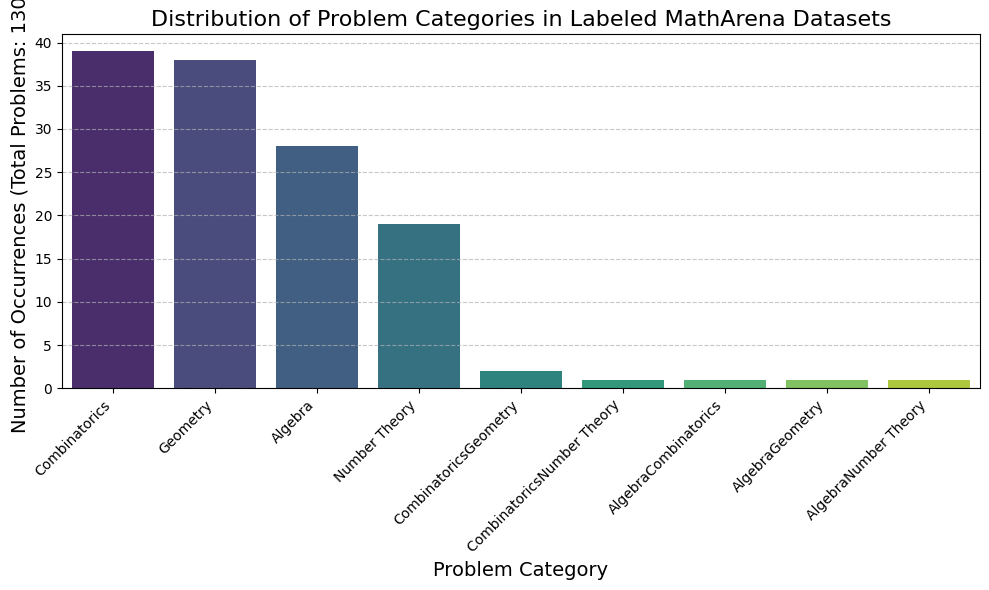

Successfully generated category_distribution.png

Category Counts:
problem_type_list
Combinatorics                 39
Geometry                      38
Algebra                       28
Number Theory                 19
CombinatoricsGeometry          2
CombinatoricsNumber Theory     1
AlgebraCombinatorics           1
AlgebraGeometry                1
AlgebraNumber Theory           1
Name: count, dtype: int64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
import itertools

# Define paths to the saved data
train_path = "data/problem_type_data.train.csv"
test_path = "data/problem_type_data.test.csv"

# Load the split dataframes
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    # Combine the data back for a full category distribution view (Total 130 problems)
    full_data_pd = pd.concat([train_df, test_df], ignore_index=True)

    # The 'problem_type' column is stored as a string representation of a list 
    # (e.g., "['Algebra', 'Number Theory']").
    # We use literal_eval to safely convert the string to an actual Python list.
    full_data_pd['problem_type_list'] = full_data_pd['problem_type'].apply(literal_eval)

    # Explode the DataFrame to get one row per problem-category pair, 
    # then count the occurrences of each category.
    category_counts = full_data_pd.explode('problem_type_list')['problem_type_list'].value_counts().sort_values(ascending=False)

    # --- Visualization: Distribution of Problem Categories ---

    plt.figure(figsize=(10, 6))
    # Create the bar plot (sorted by count by default)
    sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
    plt.title('Distribution of Problem Categories in Labeled MathArena Datasets', fontsize=16)
    plt.xlabel('Problem Category', fontsize=14)
    plt.ylabel('Number of Occurrences (Total Problems: 130)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('category_distribution.png')
    plt.show() # Use plt.show() in your notebook to display the plot

    print("Successfully generated category_distribution.png")
    print("\nCategory Counts:")
    print(category_counts)

except FileNotFoundError:
    print(f"Error: Could not find the necessary CSV files at the expected paths:")
    print(f"- {train_path}")
    print(f"- {test_path}")
    print("Please ensure you run the preceding cells (especially the one saving to CSV) in your notebook before this cell.")
except Exception as e:
    print(f"An error occurred during data processing or visualization: {e}")